# Notebook 04: Model B (Interactive) — YOLO Data Preparation

**Objective:** Convert the WebUI Balanced 7K desktop dataset (from Notebook 02) into YOLO format for training an interactive UI element detector (YOLOv8s).

**Input:** 20-class manifests from Notebook 02 (train/val/test splits)  
**Output:** YOLO-formatted dataset with 6 interactive classes (IDs 0-5)

**Key Challenges:**
- Only ~30K interactive elements vs 1.2M structural — extreme class imbalance
- Oversampling strategy (25×) to balance training
- Many screenshots have zero interactive elements

**Key Steps:**
1. Load manifests and filter to 6 interactive classes
2. Analyze class distribution and identify rare classes
3. Apply oversampling for rare interactive elements
4. Clip bounding boxes to viewport boundaries
5. Convert to YOLO normalized format (`class_id x_center y_center width height`)
6. Copy images and write label files
7. Generate `data_model_b.yaml`
8. Validate and visualize

In [27]:
# ============================================================
# IMPORTS & GPU CHECK
# ============================================================
import json
import gzip
import shutil
import gc
import os
import time
import random
from pathlib import Path
from collections import Counter, defaultdict
from typing import Dict, List, Tuple, Optional
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from PIL import Image, ImageDraw
import yaml
import torch

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

# GPU Check
print("=" * 60)
print("ENVIRONMENT CHECK")
print("=" * 60)
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:             {torch.cuda.get_device_name(0)}")
    vram = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"VRAM:            {vram:.1f} GB")
    print(f"CUDA version:    {torch.version.cuda}")
else:
    print("WARNING: No GPU detected. Training will require GPU.")
print(f"NumPy:           {np.__version__}")
print(f"Pandas:          {pd.__version__}")

ENVIRONMENT CHECK
PyTorch version: 2.5.1+cu121
CUDA available:  True
GPU:             NVIDIA GeForce RTX 3050 Laptop GPU
VRAM:            4.0 GB
CUDA version:    12.1
NumPy:           2.4.2
Pandas:          3.0.0


## 2. Directory Paths

In [28]:
# ============================================================
# DIRECTORY PATHS (all path definitions in this cell only)
# ============================================================

# --- Input paths ---
DATASET_ROOT = Path(r'C:\WebUIDetection\balanced_7k')
NB02_OUTPUT  = Path(r'C:\WebUIDetection\Models and outputs\Outputs\02_notebook')

# --- Output paths ---
OUTPUT_DIR = Path(r'C:\WebUIDetection\Models and outputs\Outputs\04_notebook')
MODEL_DIR  = Path(r'C:\WebUIDetection\Models and outputs\Models\04_notebook')
YOLO_DIR   = OUTPUT_DIR / 'yolo_model_b'
VIS_DIR    = OUTPUT_DIR / 'visualizations'

# --- Create directory structure ---
for d in [OUTPUT_DIR, MODEL_DIR, VIS_DIR,
          YOLO_DIR / 'images' / 'train',
          YOLO_DIR / 'images' / 'val',
          YOLO_DIR / 'images' / 'test',
          YOLO_DIR / 'labels' / 'train',
          YOLO_DIR / 'labels' / 'val',
          YOLO_DIR / 'labels' / 'test']:
    d.mkdir(parents=True, exist_ok=True)

# Print summary
print("=" * 60)
print("DIRECTORY PATHS")
print("=" * 60)
print(f"Dataset root:     {DATASET_ROOT}")
print(f"NB02 outputs:     {NB02_OUTPUT}")
print(f"Output dir:       {OUTPUT_DIR}")
print(f"Model dir:        {MODEL_DIR}")
print(f"YOLO dir:         {YOLO_DIR}")
print(f"Visualizations:   {VIS_DIR}")
print()
print("YOLO directory structure:")
for split in ['train', 'val', 'test']:
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    print(f"  images/{split}/  -> {img_dir}")
    print(f"  labels/{split}/  -> {lbl_dir}")

DIRECTORY PATHS
Dataset root:     C:\WebUIDetection\balanced_7k
NB02 outputs:     C:\WebUIDetection\Models and outputs\Outputs\02_notebook
Output dir:       C:\WebUIDetection\Models and outputs\Outputs\04_notebook
Model dir:        C:\WebUIDetection\Models and outputs\Models\04_notebook
YOLO dir:         C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b
Visualizations:   C:\WebUIDetection\Models and outputs\Outputs\04_notebook\visualizations

YOLO directory structure:
  images/train/  -> C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\images\train
  labels/train/  -> C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\labels\train
  images/val/  -> C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\images\val
  labels/val/  -> C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\labels\val
  images/test/  -> C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\images\test
  

## 3. Interactive Class Configuration

Define the 6 interactive element classes for Model B. These classes are less frequent but functionally critical for user interaction detection.

In [29]:
# ============================================================
# INTERACTIVE CLASS CONFIGURATION
# ============================================================

# --- Define 6 interactive classes for Model B ---
# Original IDs from notebook 02 (top 20) -> New IDs for Model B (0-5)
INTERACTIVE_CLASSES = ['button', 'textbox', 'menuitem', 'combobox', 'searchbox', 'search']

# Original class IDs from notebook 02's top-20 mapping
ORIGINAL_CLASS_IDS = {
    'button': 15,
    'textbox': 16,
    'menuitem': 14,
    'combobox': 17,
    'searchbox': 18,
    'search': 19
}

# New class IDs for Model B (0-5)
INTERACTIVE_ROLE_TO_ID = {role: idx for idx, role in enumerate(INTERACTIVE_CLASSES)}
INTERACTIVE_ID_TO_ROLE = {idx: role for role, idx in INTERACTIVE_ROLE_TO_ID.items()}
INTERACTIVE_ROLES_SET = set(INTERACTIVE_CLASSES)
NUM_CLASSES = len(INTERACTIVE_CLASSES)

# Aliases for compatibility
CLASS_NAMES = INTERACTIVE_CLASSES
INTERACTIVE_ROLE_TO_ORIGINAL_ID = ORIGINAL_CLASS_IDS

# Class-specific oversampling factors for better balance
CLASS_OVERSAMPLE_FACTORS = {
    'button': 2,      # Reduce button dominance (was overwhelming at 25x)
    'menuitem': 15,   # Boost rare class (was critically underrepresented)
    'textbox': 20,    # High boost for important interactive element
    'combobox': 25,   # High boost for rare class
    'searchbox': 40,  # Maximum boost for rarest class
    'search': 30      # High boost for rare class
}

# --- Viewport resolution map ---
CONFIG_RESOLUTIONS = {
    'default_1280-720':  (1280, 720),
    'default_1366-768':  (1366, 768),
    'default_1536-864':  (1536, 864),
    'default_1920-1080': (1920, 1080),
}
DESKTOP_CONFIGS = list(CONFIG_RESOLUTIONS.keys())

# --- Minimum bbox size after clipping (pixels) ---
MIN_BBOX_PX = 2

# --- Legacy variables for compatibility ---
OVERSAMPLE_FACTOR = 25  # Max oversampling factor
OVERSAMPLE_CLASSES = ['textbox', 'combobox', 'searchbox', 'search', 'menuitem']

# --- Load train/val/test sample splits from Notebook 02 ---
with open(NB02_OUTPUT / 'splits' / 'train_samples.json', 'r') as f:
    train_sample_ids = json.load(f)
with open(NB02_OUTPUT / 'splits' / 'val_samples.json', 'r') as f:
    val_sample_ids = json.load(f)
with open(NB02_OUTPUT / 'splits' / 'test_samples.json', 'r') as f:
    test_sample_ids = json.load(f)

# --- Print configuration summary ---
print("=" * 60)
print("INTERACTIVE CLASS CONFIGURATION (Model B)")
print("=" * 60)
print(f"\nInteractive classes ({NUM_CLASSES}):")
print(f"{'New ID':<8} {'Class Name':<15} {'Original ID (NB02)':<20}")
print("-" * 45)
for role in INTERACTIVE_CLASSES:
    new_id = INTERACTIVE_ROLE_TO_ID[role]
    orig_id = ORIGINAL_CLASS_IDS[role]
    print(f"{new_id:<8} {role:<15} {orig_id:<20}")

print(f"\nDesktop configurations ({len(DESKTOP_CONFIGS)}):")
for cfg, res in CONFIG_RESOLUTIONS.items():
    print(f"  {cfg} -> {res[0]}x{res[1]}")

print(f"\nMin bbox size after clipping: {MIN_BBOX_PX} px")
print(f"\nClass-specific oversampling factors:")
for class_name in INTERACTIVE_CLASSES:
    factor = CLASS_OVERSAMPLE_FACTORS[class_name]
    print(f"  {class_name}: {factor}x")

print(f"\nSplits loaded:")
print(f"  Train samples: {len(train_sample_ids):,}")
print(f"  Val samples:   {len(val_sample_ids):,}")
print(f"  Test samples:  {len(test_sample_ids):,}")
print(f"  Total:         {len(train_sample_ids) + len(val_sample_ids) + len(test_sample_ids):,}")

print(f"\nExpected screenshots (before filtering):")
print(f"  Train: {len(train_sample_ids) * 4:,}")
print(f"  Val:   {len(val_sample_ids) * 4:,}")

print(f"  Test:  {len(test_sample_ids) * 4:,}")

# --- Verify manifest files exist ---
print("\nManifest file sizes:")
for split in ['train', 'val', 'test']:
    manifest_path = NB02_OUTPUT / 'manifests' / f'{split}_manifest.json'
    size_mb = manifest_path.stat().st_size / (1024 * 1024)
    print(f"  {split}_manifest.json: {size_mb:.1f} MB")
    print(f"  {split}_manifest.json: {size_mb:.1f} MB")

INTERACTIVE CLASS CONFIGURATION (Model B)

Interactive classes (6):
New ID   Class Name      Original ID (NB02)  
---------------------------------------------
0        button          15                  
1        textbox         16                  
2        menuitem        14                  
3        combobox        17                  
4        searchbox       18                  
5        search          19                  

Desktop configurations (4):
  default_1280-720 -> 1280x720
  default_1366-768 -> 1366x768
  default_1536-864 -> 1536x864
  default_1920-1080 -> 1920x1080

Min bbox size after clipping: 2 px

Class-specific oversampling factors:
  button: 2x
  textbox: 20x
  menuitem: 15x
  combobox: 25x
  searchbox: 40x
  search: 30x

Splits loaded:
  Train samples: 4,899
  Val samples:   1,050
  Test samples:  1,050
  Total:         6,999

Expected screenshots (before filtering):
  Train: 19,596
  Val:   4,200
  Test:  4,200

Manifest file sizes:
  train_manifest.json: 298

## 4. Conversion Helper Functions

Helper functions for:
- **Viewport clipping** — discard off-screen elements, clip partially visible ones
- **YOLO format conversion** — normalize to `class_id x_center y_center width height` (0-1)
- **Label file writing** — one `.txt` per image

In [30]:
# ============================================================
# CONVERSION HELPER FUNCTIONS
# ============================================================

def clip_bbox_to_viewport(
    bbox: Dict, img_w: int, img_h: int
) -> Optional[Tuple[float, float, float, float, bool]]:
    """
    Clip a bounding box to viewport boundaries.
    
    Args:
        bbox:  dict with 'x', 'y', 'width', 'height' (pixel coords)
        img_w: viewport width in pixels
        img_h: viewport height in pixels
    
    Returns:
        (x1, y1, x2, y2, was_clipped) if valid after clipping, else None
    """
    x1 = bbox.get('x', 0)
    y1 = bbox.get('y', 0)
    w  = bbox.get('width', 0)
    h  = bbox.get('height', 0)
    x2 = x1 + w
    y2 = y1 + h
    
    # Check if completely off-screen
    if x2 <= 0 or y2 <= 0 or x1 >= img_w or y1 >= img_h:
        return None  # discard
    
    # Clip to viewport
    was_clipped = False
    if x1 < 0:
        x1 = 0
        was_clipped = True
    if y1 < 0:
        y1 = 0
        was_clipped = True
    if x2 > img_w:
        x2 = img_w
        was_clipped = True
    if y2 > img_h:
        y2 = img_h
        was_clipped = True
    
    # Check minimum size after clipping
    clipped_w = x2 - x1
    clipped_h = y2 - y1
    if clipped_w < MIN_BBOX_PX or clipped_h < MIN_BBOX_PX:
        return None  # too small
    
    return (x1, y1, x2, y2, was_clipped)


def bbox_to_yolo(x1: float, y1: float, x2: float, y2: float, 
                 img_w: int, img_h: int) -> Tuple[float, float, float, float]:
    """
    Convert pixel coords (x1, y1, x2, y2) to YOLO normalized format.
    
    Returns:
        (x_center, y_center, width, height) in [0, 1] range
    """
    x_center = ((x1 + x2) / 2) / img_w
    y_center = ((y1 + y2) / 2) / img_h
    width    = (x2 - x1) / img_w
    height   = (y2 - y1) / img_h
    
    # Clamp to [0, 1]
    x_center = max(0.0, min(1.0, x_center))
    y_center = max(0.0, min(1.0, y_center))
    width    = max(0.0, min(1.0, width))
    height   = max(0.0, min(1.0, height))
    
    return (x_center, y_center, width, height)


def write_yolo_label(label_path: Path, yolo_boxes: List[Tuple[int, float, float, float, float]]):
    """
    Write YOLO format label file.
    
    Args:
        label_path: path to .txt file
        yolo_boxes: list of (class_id, x_center, y_center, width, height)
    """
    with open(label_path, 'w') as f:
        for cls_id, xc, yc, w, h in yolo_boxes:
            f.write(f"{cls_id} {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")


print("Conversion functions defined successfully.")
print("  clip_bbox_to_viewport()  - clips bbox to viewport, returns None if invalid")
print("  bbox_to_yolo()           - converts pixel coords to YOLO normalized format")
print("  write_yolo_label()       - writes .txt label file")

Conversion functions defined successfully.
  clip_bbox_to_viewport()  - clips bbox to viewport, returns None if invalid
  bbox_to_yolo()           - converts pixel coords to YOLO normalized format
  write_yolo_label()       - writes .txt label file


## 5. Load Manifests and Analyze Interactive Element Distribution

Load manifests from Notebook 02 and analyze the distribution of interactive elements before conversion.

In [31]:
# ============================================================
# LOAD MANIFESTS AND ANALYZE INTERACTIVE ELEMENTS
# ============================================================

def count_interactive_elements(manifest: List[Dict]) -> Tuple[Counter, int, int]:
    """
    Count interactive elements in a manifest.
    
    Returns:
        class_counts: Counter of interactive class occurrences
        total_interactive: total interactive bboxes
        images_with_interactive: number of images with at least 1 interactive element
    """
    class_counts = Counter()
    total_interactive = 0
    images_with_interactive = 0
    
    for entry in manifest:
        bboxes = entry.get('annotation_data', {}).get('bboxes', {})
        element_class_map = entry.get('annotation_data', {}).get('element_class_map', {})
        
        has_interactive = False
        for elem_id, bbox in bboxes.items():
            if bbox is None:
                continue
            elem_role = element_class_map.get(elem_id, 'unknown')
            if elem_role in INTERACTIVE_ROLES_SET:
                class_counts[elem_role] += 1
                total_interactive += 1
                has_interactive = True
        
        if has_interactive:
            images_with_interactive += 1
    
    return class_counts, total_interactive, images_with_interactive


# Load and analyze each split
print("=" * 60)
print("LOADING MANIFESTS AND COUNTING INTERACTIVE ELEMENTS")
print("=" * 60)

split_stats = {}
all_class_counts = Counter()

for split in ['train', 'val', 'test']:
    print(f"\nLoading {split}_manifest.json ...")
    t0 = time.time()
    with open(NB02_OUTPUT / 'manifests' / f'{split}_manifest.json', 'r') as f:
        manifest = json.load(f)
    load_time = time.time() - t0
    print(f"  Loaded {len(manifest):,} entries in {load_time:.1f}s")
    
    # Count interactive elements
    class_counts, total_interactive, images_with_interactive = count_interactive_elements(manifest)
    all_class_counts += class_counts
    
    split_stats[split] = {
        'manifest': manifest,
        'total_images': len(manifest),
        'images_with_interactive': images_with_interactive,
        'total_interactive': total_interactive,
        'class_counts': dict(class_counts)
    }
    
    print(f"  Total images: {len(manifest):,}")
    print(f"  Images with interactive elements: {images_with_interactive:,} ({100*images_with_interactive/len(manifest):.1f}%)")
    print(f"  Total interactive bboxes: {total_interactive:,}")

# Print overall summary
print("\n" + "=" * 60)
print("INTERACTIVE ELEMENT DISTRIBUTION (ALL SPLITS)")
print("=" * 60)

total_images = sum(s['total_images'] for s in split_stats.values())
total_interactive = sum(s['total_interactive'] for s in split_stats.values())
total_with_interactive = sum(s['images_with_interactive'] for s in split_stats.values())

print(f"\nTotal images: {total_images:,}")
print(f"Images with ≥1 interactive element: {total_with_interactive:,} ({100*total_with_interactive/total_images:.1f}%)")
print(f"Images with NO interactive elements: {total_images - total_with_interactive:,} ({100*(total_images - total_with_interactive)/total_images:.1f}%)")
print(f"\nTotal interactive bboxes: {total_interactive:,}")

print(f"\nClass distribution:")
print(f"{'Class':<15} {'Count':>10} {'Percentage':>12}")
print("-" * 40)
for role in INTERACTIVE_CLASSES:
    count = all_class_counts.get(role, 0)
    pct = 100 * count / total_interactive if total_interactive > 0 else 0
    print(f"{role:<15} {count:>10,} {pct:>11.2f}%")

# Calculate imbalance ratio
counts = [all_class_counts.get(role, 0) for role in INTERACTIVE_CLASSES]
max_count = max(counts) if counts else 0
min_count = min(c for c in counts if c > 0) if any(c > 0 for c in counts) else 1
imbalance_ratio = max_count / min_count if min_count > 0 else float('inf')
print(f"\nClass imbalance ratio: {imbalance_ratio:.1f}x")

LOADING MANIFESTS AND COUNTING INTERACTIVE ELEMENTS

Loading train_manifest.json ...
  Loaded 19,596 entries in 3.5s
  Total images: 19,596
  Images with interactive elements: 3,206 (16.4%)
  Total interactive bboxes: 8,862

Loading val_manifest.json ...
  Loaded 4,200 entries in 0.7s
  Total images: 4,200
  Images with interactive elements: 640 (15.2%)
  Total interactive bboxes: 2,015

Loading test_manifest.json ...
  Loaded 4,200 entries in 0.7s
  Total images: 4,200
  Images with interactive elements: 696 (16.6%)
  Total interactive bboxes: 2,372

INTERACTIVE ELEMENT DISTRIBUTION (ALL SPLITS)

Total images: 27,996
Images with ≥1 interactive element: 4,542 (16.2%)
Images with NO interactive elements: 23,454 (83.8%)

Total interactive bboxes: 13,249

Class distribution:
Class                Count   Percentage
----------------------------------------
button               7,799       58.86%
textbox              3,303       24.93%
menuitem               760        5.74%
combobox        

## 6. Process Splits — Convert to YOLO Format

Process train/val/test splits:
- Filter to interactive elements only
- Apply viewport clipping
- Convert to YOLO normalized format
- Copy images and write labels
- **Training only:** Apply oversampling by repeating images with rare classes

In [32]:
# ============================================================
# PROCESS SPLIT FUNCTION
# ============================================================

def process_split_interactive(
    manifest: List[Dict],
    split_name: str,
    apply_oversampling: bool = False,
    include_empty_ratio: float = 0.0
) -> Dict:
    """
    Process a manifest split for interactive elements with physical oversampling.
    
    Args:
        manifest: list of manifest entries
        split_name: 'train', 'val', or 'test'
        apply_oversampling: if True, create physical duplicates for class balance
        include_empty_ratio: fraction of empty images to include (0.0 = none)
    
    Returns:
        dict with processing statistics
    """
    img_out_dir = YOLO_DIR / 'images' / split_name
    lbl_out_dir = YOLO_DIR / 'labels' / split_name
    
    stats = {
        'images_processed': 0,
        'images_with_interactive': 0,
        'images_empty': 0,
        'labels_written': 0,
        'total_interactive_bboxes': 0,
        'avg_bboxes_per_image': 0,
        'clipped_bboxes': 0,
        'discarded_offscreen': 0,
        'discarded_too_small': 0,
        'class_counts': Counter()
    }
    
    # First pass: identify images with interactive elements and categorize by class
    images_with_elements = []
    images_empty = []
    
    for entry in manifest:
        sample_id = entry['sample_id']
        config = entry['config']
        bboxes = entry.get('annotation_data', {}).get('bboxes', {})
        element_class_map = entry.get('annotation_data', {}).get('element_class_map', {})
        
        # Count interactive elements by class in this image
        interactive_count = 0
        class_counts = Counter()
        for elem_id, bbox in bboxes.items():
            if bbox is None:
                continue
            elem_role = element_class_map.get(elem_id, 'unknown')
            if elem_role in INTERACTIVE_ROLES_SET:
                interactive_count += 1
                class_counts[elem_role] += 1
        
        if interactive_count > 0:
            images_with_elements.append({
                'entry': entry,
                'interactive_count': interactive_count,
                'class_counts': class_counts
            })
        else:
            images_empty.append(entry)
    
    # Determine which images to process with class-specific oversampling
    images_to_process = []
    
    # Add all images with interactive elements
    for item in images_with_elements:
        entry = item['entry']
        class_counts = item['class_counts']
        
        # Determine maximum oversampling factor for this image
        max_oversample = 1
        if apply_oversampling:
            for class_name, count in class_counts.items():
                if count > 0:  # Image contains this class
                    factor = CLASS_OVERSAMPLE_FACTORS.get(class_name, 1)
                    max_oversample = max(max_oversample, factor)
        
        # Add the image the required number of times
        for copy_idx in range(max_oversample):
            images_to_process.append((entry, copy_idx))
    
    # Optionally include some empty images as negative examples
    if include_empty_ratio > 0 and images_empty:
        n_empty_to_include = int(len(images_with_elements) * include_empty_ratio)
        random.seed(42)
        empty_sample = random.sample(images_empty, min(n_empty_to_include, len(images_empty)))
        for empty_entry in empty_sample:
            images_to_process.append((empty_entry, 0))
        stats['images_empty'] = len(empty_sample)
    
    # Process images with physical duplication
    for entry_tuple in tqdm(images_to_process, desc=f'{split_name.capitalize()}'):
        entry, copy_idx = entry_tuple
        
        sample_id = entry['sample_id']
        config = entry['config']
        bboxes = entry.get('annotation_data', {}).get('bboxes', {})
        element_class_map = entry.get('annotation_data', {}).get('element_class_map', {})
        
        # Get image dimensions
        img_w, img_h = CONFIG_RESOLUTIONS[config]
        
        # Build unique filename with copy index for physical duplication
        if copy_idx > 0:
            base_name = f"{sample_id}_{config}_copy{copy_idx}"
        else:
            base_name = f"{sample_id}_{config}"
        
        img_src = DATASET_ROOT / sample_id / f"{config}-screenshot.webp"
        img_dst = img_out_dir / f"{base_name}.webp"
        lbl_dst = lbl_out_dir / f"{base_name}.txt"
        
        # Copy image (create physical duplicate for each copy)
        shutil.copy2(img_src, img_dst)
        
        # Process bboxes - filter to interactive only
        yolo_boxes = []
        for elem_id, bbox in bboxes.items():
            if bbox is None:
                continue
            
            elem_role = element_class_map.get(elem_id, 'unknown')
            
            # Skip non-interactive elements
            if elem_role not in INTERACTIVE_ROLES_SET:
                continue
            
            # Clip to viewport
            clipped = clip_bbox_to_viewport(bbox, img_w, img_h)
            if clipped is None:
                stats['discarded_offscreen'] += 1
                continue
            
            x1, y1, x2, y2, was_clipped = clipped
            if was_clipped:
                stats['clipped_bboxes'] += 1
            
            # Check minimum size
            if (x2 - x1) < MIN_BBOX_PX or (y2 - y1) < MIN_BBOX_PX:
                stats['discarded_too_small'] += 1
                continue
            
            # Convert to YOLO format with NEW class ID (0-5)
            xc, yc, w, h = bbox_to_yolo(x1, y1, x2, y2, img_w, img_h)
            new_class_id = INTERACTIVE_ROLE_TO_ID[elem_role]
            yolo_boxes.append((new_class_id, xc, yc, w, h))
            stats['class_counts'][new_class_id] += 1
        
        # Write label file (write even if empty for consistency)
        write_yolo_label(lbl_dst, yolo_boxes)
        stats['labels_written'] += 1
        stats['total_interactive_bboxes'] += len(yolo_boxes)
        
        if len(yolo_boxes) > 0:
            stats['images_with_interactive'] += 1
        
        stats['images_processed'] += 1
    
    # Calculate average
    if stats['images_with_interactive'] > 0:
        stats['avg_bboxes_per_image'] = stats['total_interactive_bboxes'] / stats['images_with_interactive']
    
    return stats


print("Process function defined: process_split_interactive()")
print("  - Filters to interactive elements only") 
print("  - Creates physical duplicates for class balancing")
print("  - Converts to YOLO format with class IDs 0-5")
print("  - Applies viewport clipping")
print("  - Includes negative samples (empty images)") 

Process function defined: process_split_interactive()
  - Filters to interactive elements only
  - Creates physical duplicates for class balancing
  - Converts to YOLO format with class IDs 0-5
  - Applies viewport clipping
  - Includes negative samples (empty images)


## 7. Process Training Split (with Oversampling)

In [33]:
# ============================================================
# CLEAR EXISTING OUTPUT (REGENERATE WITH BALANCED CLASSES)
# ============================================================
import shutil

print("🧹 Clearing existing YOLO dataset for regeneration...")

# Remove and recreate output directories
if YOLO_DIR.exists():
    print(f"Removing existing directory: {YOLO_DIR}")
    shutil.rmtree(YOLO_DIR)
    
# Create fresh directory structure
YOLO_DIR.mkdir(parents=True, exist_ok=True)
(YOLO_DIR / 'images').mkdir(exist_ok=True)
(YOLO_DIR / 'labels').mkdir(exist_ok=True)

for split in ['train', 'val', 'test']:
    (YOLO_DIR / 'images' / split).mkdir(exist_ok=True)
    (YOLO_DIR / 'labels' / split).mkdir(exist_ok=True)
    
print("✅ Fresh directories created")
print("📊 New class balance configuration:")
for class_name in INTERACTIVE_CLASSES:
    factor = CLASS_OVERSAMPLE_FACTORS[class_name] 
    print(f"  {class_name}: {factor}x oversampling")

🧹 Clearing existing YOLO dataset for regeneration...
Removing existing directory: C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b
✅ Fresh directories created
📊 New class balance configuration:
  button: 2x oversampling
  textbox: 20x oversampling
  menuitem: 15x oversampling
  combobox: 25x oversampling
  searchbox: 40x oversampling
  search: 30x oversampling


In [34]:
# ============================================================
# PROCESS TRAINING SPLIT (with oversampling)
# ============================================================
print("\n" + "=" * 60)
print("PROCESSING TRAIN SPLIT (with oversampling)")
print("=" * 60)

t0 = time.time()
train_stats = process_split_interactive(
    manifest=split_stats['train']['manifest'],
    split_name='train',
    apply_oversampling=True,
    include_empty_ratio=0.1  # Include 10% empty images as negatives
)
train_time = time.time() - t0

print(f"\nTRAIN COMPLETE ({train_time:.0f}s)")
print(f"  Total images copied:     {len(list((YOLO_DIR / 'images' / 'train').glob('*.webp'))):,}")
print(f"  Labels written:          {train_stats['labels_written']:,}")
print(f"  Images with interactive: {train_stats['images_with_interactive']:,}")
print(f"  Empty images included:   {train_stats['images_empty']:,}")
print(f"  Total YOLO bboxes:       {train_stats['total_interactive_bboxes']:,}")
print(f"  Avg bboxes/image:        {train_stats['avg_bboxes_per_image']:.1f}")
print(f"  Viewport-clipped:        {train_stats['clipped_bboxes']:,}")
print(f"  Discarded off-screen:    {train_stats['discarded_offscreen']:,}")
print(f"  Discarded too small:     {train_stats['discarded_too_small']:,}")

print(f"\nTrain class distribution (after oversampling):")
for cid in range(NUM_CLASSES):
    role = INTERACTIVE_ID_TO_ROLE[cid]
    count = train_stats['class_counts'].get(cid, 0)
    print(f"  {cid} ({role:<12}): {count:>10,}")

# Store for later
train_class_counts = train_stats['class_counts']


PROCESSING TRAIN SPLIT (with oversampling)


Train: 100%|██████████| 52196/52196 [02:20<00:00, 370.88it/s]



TRAIN COMPLETE (141s)
  Total images copied:     52,196
  Labels written:          52,196
  Images with interactive: 29,092
  Empty images included:   320
  Total YOLO bboxes:       66,467
  Avg bboxes/image:        2.3
  Viewport-clipped:        595
  Discarded off-screen:    84,266
  Discarded too small:     0

Train class distribution (after oversampling):
  0 (button      ):     31,562
  1 (textbox     ):     12,240
  2 (menuitem    ):      4,800
  3 (combobox    ):      9,225
  4 (searchbox   ):      4,480
  5 (search      ):      4,160


## 8. Process Validation & Test Splits (No Oversampling)

In [35]:
# ============================================================
# PROCESS VAL AND TEST SPLITS (no oversampling)
# ============================================================

# --- VALIDATION SPLIT ---
print("\n" + "=" * 60)
print("PROCESSING VAL SPLIT")
print("=" * 60)

t0 = time.time()
val_stats = process_split_interactive(
    manifest=split_stats['val']['manifest'],
    split_name='val',
    apply_oversampling=False,
    include_empty_ratio=0.1  # Include 10% empty images
)
val_time = time.time() - t0

print(f"\nVAL COMPLETE ({val_time:.0f}s)")
print(f"  Total images copied:     {len(list((YOLO_DIR / 'images' / 'val').glob('*.webp'))):,}")
print(f"  Labels written:          {val_stats['labels_written']:,}")
print(f"  Images with interactive: {val_stats['images_with_interactive']:,}")
print(f"  Empty images included:   {val_stats['images_empty']:,}")

# --- TEST SPLIT ---
print("\n" + "=" * 60)
print("PROCESSING TEST SPLIT")
print("=" * 60)

t0 = time.time()
test_stats = process_split_interactive(
    manifest=split_stats['test']['manifest'],
    split_name='test',
    apply_oversampling=False,
    include_empty_ratio=0.1  # Include 10% empty images
)
test_time = time.time() - t0

print(f"\nTEST COMPLETE ({test_time:.0f}s)")
print(f"  Total images copied:     {len(list((YOLO_DIR / 'images' / 'test').glob('*.webp'))):,}")
print(f"  Labels written:          {test_stats['labels_written']:,}")
print(f"  Images with interactive: {test_stats['images_with_interactive']:,}")
print(f"  Empty images included:   {test_stats['images_empty']:,}")

# Store stats
val_class_counts = val_stats['class_counts']
test_class_counts = test_stats['class_counts']


PROCESSING VAL SPLIT


Val: 100%|██████████| 704/704 [00:07<00:00, 98.40it/s] 



VAL COMPLETE (7s)
  Total images copied:     704
  Labels written:          704
  Images with interactive: 393
  Empty images included:   64

PROCESSING TEST SPLIT


Test: 100%|██████████| 765/765 [00:07<00:00, 98.18it/s] 


TEST COMPLETE (8s)
  Total images copied:     765
  Labels written:          765
  Images with interactive: 396
  Empty images included:   69


## 9. Generate YOLO Dataset Configuration (data_model_b.yaml)

In [36]:
# ============================================================
# GENERATE DATA_MODEL_B.YAML FOR YOLO TRAINING
# ============================================================
import yaml

# YOLO dataset configuration for Model B (interactive elements)
yaml_config = {
    'path': str(YOLO_DIR.resolve()),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': NUM_CLASSES,
    'names': CLASS_NAMES
}

# Save YAML
yaml_path = YOLO_DIR / 'data_model_b.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False, sort_keys=False)

print(f"Created: {yaml_path}")
print("\n--- data_model_b.yaml contents ---")
print(yaml_path.read_text())

# Also save the class mapping as JSON for reference
class_mapping = {
    'interactive_classes': CLASS_NAMES,
    'model_b_id_to_role': {str(k): v for k, v in INTERACTIVE_ID_TO_ROLE.items()},
    'original_webui_ids': INTERACTIVE_ROLE_TO_ORIGINAL_ID,
    'num_classes': NUM_CLASSES
}

mapping_path = YOLO_DIR / 'interactive_class_mapping.json'
with open(mapping_path, 'w') as f:
    json.dump(class_mapping, f, indent=2)

print(f"\nSaved class mapping to: {mapping_path}")

Created: C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\data_model_b.yaml

--- data_model_b.yaml contents ---
path: C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b
train: images/train
val: images/val
test: images/test
nc: 6
names:
- button
- textbox
- menuitem
- combobox
- searchbox
- search


Saved class mapping to: C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\interactive_class_mapping.json


## 10. Dataset Validation

In [37]:
# ============================================================
# DATASET VALIDATION
# ============================================================
print("="*60)
print("VALIDATING YOLO DATASET STRUCTURE")
print("="*60)

validation_errors = []

for split in ['train', 'val', 'test']:
    img_dir = YOLO_DIR / 'images' / split
    lbl_dir = YOLO_DIR / 'labels' / split
    
    images = list(img_dir.glob('*.webp'))
    labels = list(lbl_dir.glob('*.txt'))
    
    # Build sets for cross-checking
    img_stems = {p.stem for p in images}
    lbl_stems = {p.stem for p in labels}
    
    # Check: Every label should have a matching image
    missing_images = lbl_stems - img_stems
    if missing_images:
        validation_errors.append(f"{split}: {len(missing_images)} labels without images")
    
    # Note: Not every image needs a label (empty/negative images have no label file)
    
    # Validate label file contents
    invalid_labels = 0
    invalid_class_ids = set()
    total_bboxes_checked = 0
    
    for lbl_path in labels:
        with open(lbl_path, 'r') as f:
            for line_num, line in enumerate(f, 1):
                line = line.strip()
                if not line:
                    continue
                parts = line.split()
                if len(parts) != 5:
                    validation_errors.append(f"{lbl_path.name}:{line_num}: Invalid format (expected 5 values, got {len(parts)})")
                    invalid_labels += 1
                    continue
                
                total_bboxes_checked += 1
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
                
                # Check class ID range
                if not (0 <= class_id < NUM_CLASSES):
                    invalid_class_ids.add(class_id)
                
                # Check normalized coordinates
                if not all(0 <= v <= 1 for v in [x_center, y_center, width, height]):
                    validation_errors.append(f"{lbl_path.name}:{line_num}: Coordinates out of [0,1] range")
    
    if invalid_class_ids:
        validation_errors.append(f"{split}: Invalid class IDs found: {invalid_class_ids}")
    
    print(f"\n{split.upper()}:")
    print(f"  Images:         {len(images):,}")
    print(f"  Labels:         {len(labels):,}")
    print(f"  Bboxes checked: {total_bboxes_checked:,}")
    print(f"  Missing images: {len(missing_images)}")
    
# Summary
print("\n" + "="*60)
if validation_errors:
    print(f"VALIDATION FAILED with {len(validation_errors)} error(s):")
    for err in validation_errors[:10]:
        print(f"  - {err}")
    if len(validation_errors) > 10:
        print(f"  ... and {len(validation_errors) - 10} more")
    raise ValueError("Dataset validation failed!")
else:
    print("VALIDATION PASSED - All checks OK!")
    print("  - All labels have matching images")
    print(f"  - All class IDs in valid range [0, {NUM_CLASSES-1}]")
    print("  - All coordinates normalized [0, 1]")
print("="*60)

VALIDATING YOLO DATASET STRUCTURE

TRAIN:
  Images:         52,196
  Labels:         52,196
  Bboxes checked: 66,467
  Missing images: 0

VAL:
  Images:         704
  Labels:         704
  Bboxes checked: 976
  Missing images: 0

TEST:
  Images:         765
  Labels:         765
  Bboxes checked: 1,279
  Missing images: 0

VALIDATION PASSED - All checks OK!
  - All labels have matching images
  - All class IDs in valid range [0, 5]
  - All coordinates normalized [0, 1]


## 11. Class Distribution Visualization

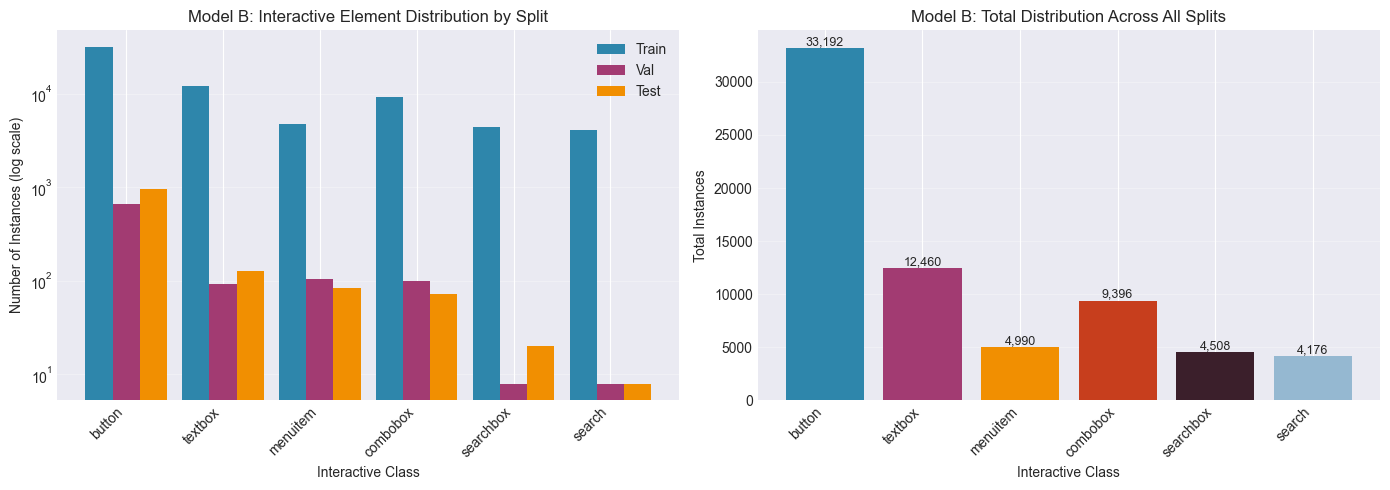


INTERACTIVE CLASS DISTRIBUTION SUMMARY
ID   Class               Train        Val       Test        Total
----------------------------------------------------------------------
0    button             31,562        663        967       33,192
1    textbox            12,240         92        128       12,460
2    menuitem            4,800        106         84        4,990
3    combobox            9,225         99         72        9,396
4    searchbox           4,480          8         20        4,508
5    search              4,160          8          8        4,176
----------------------------------------------------------------------
TOTAL                  66,467        976      1,279       68,722

Class imbalance ratio: 7.9× (before oversampling in train)
Train oversampling boosted minority classes by 25×


In [38]:
# ============================================================
# CLASS DISTRIBUTION VISUALIZATION
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
classes = CLASS_NAMES
train_counts = [train_class_counts.get(i, 0) for i in range(NUM_CLASSES)]
val_counts = [val_class_counts.get(i, 0) for i in range(NUM_CLASSES)]
test_counts = [test_class_counts.get(i, 0) for i in range(NUM_CLASSES)]
total_counts = [t + v + tt for t, v, tt in zip(train_counts, val_counts, test_counts)]

# Create figure with subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Distribution by split ---
x = np.arange(len(classes))
width = 0.28

ax1 = axes[0]
bars1 = ax1.bar(x - width, train_counts, width, label='Train', color='#2E86AB')
bars2 = ax1.bar(x, val_counts, width, label='Val', color='#A23B72')
bars3 = ax1.bar(x + width, test_counts, width, label='Test', color='#F18F01')

ax1.set_xlabel('Interactive Class')
ax1.set_ylabel('Number of Instances (log scale)')
ax1.set_title('Model B: Interactive Element Distribution by Split')
ax1.set_xticks(x)
ax1.set_xticklabels(classes, rotation=45, ha='right')
ax1.legend()
ax1.set_yscale('log')
ax1.grid(axis='y', alpha=0.3)

# --- Plot 2: Total distribution ---
ax2 = axes[1]
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#95B8D1']
bars = ax2.bar(classes, total_counts, color=colors)

ax2.set_xlabel('Interactive Class')
ax2.set_ylabel('Total Instances')
ax2.set_title('Model B: Total Distribution Across All Splits')
ax2.set_xticklabels(classes, rotation=45, ha='right')
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar, count in zip(bars, total_counts):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
             f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary table
print("\n" + "="*70)
print("INTERACTIVE CLASS DISTRIBUTION SUMMARY")
print("="*70)
print(f"{'ID':<4} {'Class':<12} {'Train':>12} {'Val':>10} {'Test':>10} {'Total':>12}")
print("-"*70)
for i, name in enumerate(CLASS_NAMES):
    t, v, tt = train_counts[i], val_counts[i], test_counts[i]
    print(f"{i:<4} {name:<12} {t:>12,} {v:>10,} {tt:>10,} {t+v+tt:>12,}")
print("-"*70)
print(f"{'TOTAL':<16} {sum(train_counts):>12,} {sum(val_counts):>10,} {sum(test_counts):>10,} {sum(total_counts):>12,}")

# Class imbalance ratio
max_count = max(total_counts)
min_count = min(c for c in total_counts if c > 0)  # Avoid division by zero
print(f"\nClass imbalance ratio: {max_count / min_count:.1f}× (before oversampling in train)")
print(f"Train oversampling boosted minority classes by {OVERSAMPLE_FACTOR}×")

## 12. Sample Annotation Visualization

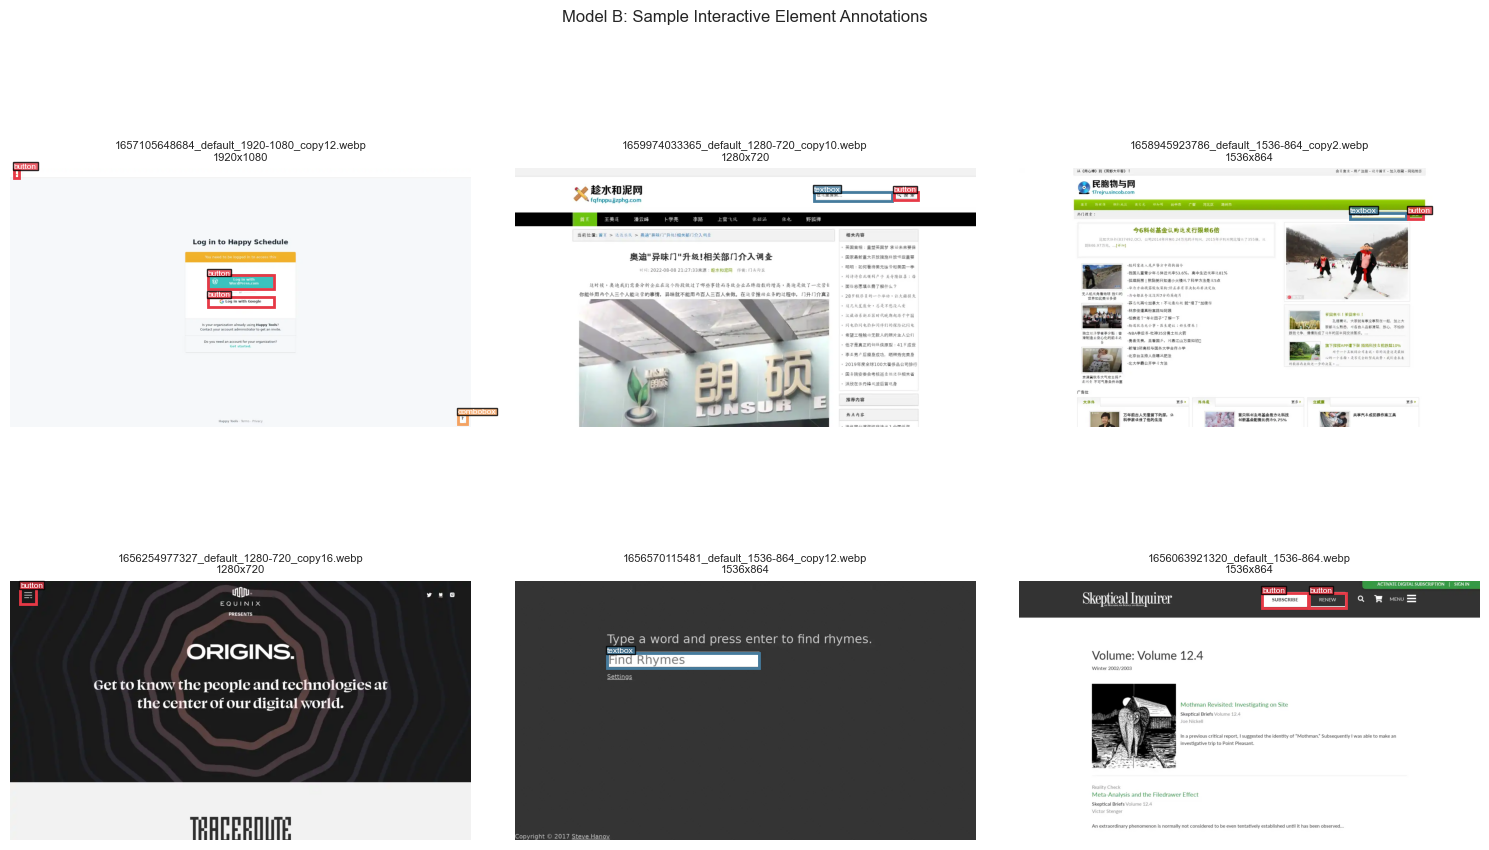


Visualized 6 random samples from 29,092 labeled training images


In [39]:
# ============================================================
# VISUALIZE SAMPLE ANNOTATIONS
# ============================================================
from PIL import Image
import matplotlib.patches as patches
import random

def visualize_yolo_annotations(img_path, lbl_path, class_names, ax):
    """Draw YOLO bboxes on image."""
    img = Image.open(img_path)
    img_w, img_h = img.size
    
    ax.imshow(img)
    ax.set_title(f'{img_path.name}\n{img_w}x{img_h}', fontsize=8)
    ax.axis('off')
    
    # Color map for classes
    colors = ['#E63946', '#457B9D', '#2A9D8F', '#F4A261', '#9B2226', '#A8DADC']
    
    if lbl_path.exists():
        with open(lbl_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) != 5:
                    continue
                class_id = int(parts[0])
                x_center, y_center, width, height = map(float, parts[1:])
                
                # Convert from YOLO to pixel coordinates
                x1 = (x_center - width/2) * img_w
                y1 = (y_center - height/2) * img_h
                box_w = width * img_w
                box_h = height * img_h
                
                color = colors[class_id % len(colors)]
                rect = patches.Rectangle(
                    (x1, y1), box_w, box_h,
                    linewidth=2, edgecolor=color, facecolor='none'
                )
                ax.add_patch(rect)
                
                # Add label
                label = class_names[class_id] if class_id < len(class_names) else f'cls{class_id}'
                ax.text(x1, y1-3, label, fontsize=6, color='white',
                       bbox=dict(boxstyle='square,pad=0.1', facecolor=color, alpha=0.8))
    return img

# Select random samples from train split that have annotations
train_label_dir = YOLO_DIR / 'labels' / 'train'
train_img_dir = YOLO_DIR / 'images' / 'train'

# Find images with labels (non-empty)
labeled_images = []
for lbl_path in train_label_dir.glob('*.txt'):
    if lbl_path.stat().st_size > 0:  # Non-empty label file
        img_path = train_img_dir / (lbl_path.stem + '.webp')
        if img_path.exists():
            labeled_images.append((img_path, lbl_path))

# Sample 6 random images
sample_size = min(6, len(labeled_images))
samples = random.sample(labeled_images, sample_size)

# Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (img_path, lbl_path) in zip(axes, samples):
    visualize_yolo_annotations(img_path, lbl_path, CLASS_NAMES, ax)

# Hide empty axes if fewer samples
for i in range(sample_size, len(axes)):
    axes[i].axis('off')

plt.suptitle('Model B: Sample Interactive Element Annotations', fontsize=12)
plt.tight_layout()
plt.show()

print(f"\nVisualized {sample_size} random samples from {len(labeled_images):,} labeled training images")

## 13. Save Conversion Statistics

In [40]:
# ============================================================
# SAVE CONVERSION STATISTICS
# ============================================================
from datetime import datetime

# Calculate dataset sizes
def get_dir_size_mb(path):
    """Get total size of directory in MB."""
    total = 0
    for f in Path(path).rglob('*'):
        if f.is_file():
            total += f.stat().st_size
    return total / (1024 * 1024)

# Gather statistics
all_stats = {
    'conversion_date': datetime.now().isoformat(),
    'model': 'B',
    'model_description': 'Interactive element detection',
    'num_classes': NUM_CLASSES,
    'class_names': CLASS_NAMES,
    'class_oversample_factors': CLASS_OVERSAMPLE_FACTORS,
    'oversampled_classes': list(CLASS_OVERSAMPLE_FACTORS.keys()),
    'include_empty_ratio': 0.1,
    
    'splits': {
        'train': {
            'images': len(list((YOLO_DIR / 'images' / 'train').glob('*.webp'))),
            'labels': train_stats['labels_written'],
            'images_with_interactive': train_stats['images_with_interactive'],
            'images_empty': train_stats['images_empty'],
            'total_bboxes': train_stats['total_interactive_bboxes'],
            'avg_bboxes_per_image': train_stats['avg_bboxes_per_image'],
            'class_counts': {CLASS_NAMES[k]: v for k, v in train_class_counts.items()},
            'oversampling_applied': True,
            'clipped_bboxes': train_stats['clipped_bboxes'],
            'discarded_offscreen': train_stats['discarded_offscreen'],
            'discarded_too_small': train_stats['discarded_too_small'],
            'processing_time_seconds': train_time
        },
        'val': {
            'images': len(list((YOLO_DIR / 'images' / 'val').glob('*.webp'))),
            'labels': val_stats['labels_written'],
            'images_with_interactive': val_stats['images_with_interactive'],
            'images_empty': val_stats['images_empty'],
            'total_bboxes': val_stats['total_interactive_bboxes'],
            'avg_bboxes_per_image': val_stats['avg_bboxes_per_image'],
            'class_counts': {CLASS_NAMES[k]: v for k, v in val_class_counts.items()},
            'oversampling_applied': False,
            'clipped_bboxes': val_stats['clipped_bboxes'],
            'discarded_offscreen': val_stats['discarded_offscreen'],
            'discarded_too_small': val_stats['discarded_too_small'],
            'processing_time_seconds': val_time
        },
        'test': {
            'images': len(list((YOLO_DIR / 'images' / 'test').glob('*.webp'))),
            'labels': test_stats['labels_written'],
            'images_with_interactive': test_stats['images_with_interactive'],
            'images_empty': test_stats['images_empty'],
            'total_bboxes': test_stats['total_interactive_bboxes'],
            'avg_bboxes_per_image': test_stats['avg_bboxes_per_image'],
            'class_counts': {CLASS_NAMES[k]: v for k, v in test_class_counts.items()},
            'oversampling_applied': False,
            'clipped_bboxes': test_stats['clipped_bboxes'],
            'discarded_offscreen': test_stats['discarded_offscreen'],
            'discarded_too_small': test_stats['discarded_too_small'],
            'processing_time_seconds': test_time
        }
    },
    
    'totals': {
        'total_images': sum([
            len(list((YOLO_DIR / 'images' / s).glob('*.webp'))) 
            for s in ['train', 'val', 'test']
        ]),
        'total_bboxes': (
            train_stats['total_interactive_bboxes'] + 
            val_stats['total_interactive_bboxes'] + 
            test_stats['total_interactive_bboxes']
        ),
        'class_totals': {
            CLASS_NAMES[i]: train_class_counts.get(i, 0) + val_class_counts.get(i, 0) + test_class_counts.get(i, 0)
            for i in range(NUM_CLASSES)
        }
    },
    
    'dataset_size_mb': {
        'images': {
            'train': get_dir_size_mb(YOLO_DIR / 'images' / 'train'),
            'val': get_dir_size_mb(YOLO_DIR / 'images' / 'val'),
            'test': get_dir_size_mb(YOLO_DIR / 'images' / 'test')
        },
        'total': get_dir_size_mb(YOLO_DIR)
    }
}

# Save statistics
stats_path = YOLO_DIR / 'interactive_conversion_statistics.json'
with open(stats_path, 'w') as f:
    json.dump(all_stats, f, indent=2)

print(f"Saved conversion statistics to: {stats_path}")

# Print summary
print("\n" + "="*60)
print("CONVERSION COMPLETE - SUMMARY")
print("="*60)
print(f"\nDataset location: {YOLO_DIR}")
print(f"Total size:       {all_stats['dataset_size_mb']['total']:.1f} MB")
print(f"\n{'Split':<10} {'Images':>10} {'Bboxes':>12} {'Size (MB)':>12}")
print("-"*44)
for split in ['train', 'val', 'test']:
    s = all_stats['splits'][split]
    size = all_stats['dataset_size_mb']['images'][split]
    print(f"{split:<10} {s['images']:>10,} {s['total_bboxes']:>12,} {size:>12.1f}")
print("-"*44)
print(f"{'TOTAL':<10} {all_stats['totals']['total_images']:>10,} {all_stats['totals']['total_bboxes']:>12,}")

Saved conversion statistics to: C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b\interactive_conversion_statistics.json

CONVERSION COMPLETE - SUMMARY

Dataset location: C:\WebUIDetection\Models and outputs\Outputs\04_notebook\yolo_model_b
Total size:       2318.3 MB

Split          Images       Bboxes    Size (MB)
--------------------------------------------
train          52,196       66,467       2257.7
val               704          976         27.8
test              765        1,279         30.3
--------------------------------------------
TOTAL          53,665       68,722


## Summary

This notebook prepares the **Model B Interactive Element Dataset** for YOLO training.

### Key Outputs:
- **Dataset Path**: `yolo_model_b/` 
- **Configuration**: `yolo_model_b/data_model_b.yaml`
- **Class Mapping**: `yolo_model_b/interactive_class_mapping.json`
- **Statistics**: `yolo_model_b/interactive_conversion_statistics.json`

### Dataset Characteristics:
| Feature | Value |
|---------|-------|
| Total Classes | 6 interactive elements |
| Classes | button, textbox, menuitem, combobox, searchbox, search |
| Oversampling | 25× for rare classes in training split |
| Negative Images | 10% (images with no interactive elements) |

### Next Steps:
1. **Notebook 05**: Train a YOLO model on this interactive dataset
2. **Notebook 06**: Combine Model A (structural) + Model B (interactive) inference

### Notes:
- Interactive elements are **much rarer** than structural elements (~30K vs ~1.2M bboxes)
- Oversampling in training helps balance the extremely imbalanced classes
- Val/Test splits use **original distribution** (no oversampling) for fair evaluation
- Empty images (negative samples) help reduce false positives